## Add available landcover information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
#landcover data go up to 2021, update file when available

In [6]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv', encoding=enc)
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()


In [7]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-08-01,κεντρικης μακεδονιας,αλεξανδρειας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.643586,0.286920,-0.556377,-0.286920,0.605056,0.249669,-0.524685,-0.249669,0.049938,0.047192,0.036807,0.047192,NaN,NaN,NaN,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,0.000000,0.000000,193.267057,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,45,0,0
1,21.94079,40.97703,2023-08-01,κεντρικης μακεδονιας,αλμωπιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.684224,0.247478,-0.582804,-0.247478,0.685061,0.254445,-0.588224,-0.254445,0.042813,0.041052,0.033081,0.041052,NaN,NaN,NaN,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,0.000000,0.000000,368.218937,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,42,0,0
2,22.89198,40.65603,2023-08-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.120373,-0.034643,-0.146801,0.034643,0.167556,-0.019816,-0.189667,0.019816,0.065214,0.028184,0.056665,0.028184,NaN,NaN,NaN,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,0.000000,0.000000,416.613286,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,112,0,0
3,23.98253,40.91510,2023-08-01,κεντρικης μακεδονιας,αμφιπολης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.519325,0.160657,-0.478508,-0.160657,0.500319,0.147885,-0.465534,-0.147885,0.068396,0.079867,0.037722,0.079867,NaN,NaN,NaN,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,0.000000,0.000000,116.959709,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,55,0,0
4,23.69108,40.49593,2023-08-01,κεντρικης μακεδονιας,αριστοτελη,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.696956,0.286483,-0.595803,-0.286483,0.686754,0.287477,-0.588401,-0.287477,0.053093,0.046406,0.034712,0.046406,NaN,NaN,NaN,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,1.765248,1.765248,339.473701,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,46,0,0


In [8]:
landcover.head()

,x,y,2001_01_01_lc_prop1,2001_01_01_lc_prop1_assessment,2001_01_01_lc_prop2,2001_01_01_lc_prop2_assessment,2001_01_01_lc_prop3,2001_01_01_lc_prop3_assessment,2001_01_01_lc_type1,2001_01_01_lc_type2,2001_01_01_lc_type3,2001_01_01_lc_type4,2001_01_01_lc_type5,2001_01_01_lw,2001_01_01_qc,2002_01_01_lc_prop1,2002_01_01_lc_prop1_assessment,2002_01_01_lc_prop2,2002_01_01_lc_prop2_assessment,2002_01_01_lc_prop3,2002_01_01_lc_prop3_assessment,2002_01_01_lc_type1,2002_01_01_lc_type2,2002_01_01_lc_type3,2002_01_01_lc_type4,2002_01_01_lc_type5,2002_01_01_lw,2002_01_01_qc,2003_01_01_lc_prop1,2003_01_01_lc_prop1_assessment,2003_01_01_lc_prop2,2003_01_01_lc_prop2_assessment,2003_01_01_lc_prop3,2003_01_01_lc_prop3_assessment,2003_01_01_lc_type1,2003_01_01_lc_type2,2003_01_01_lc_type3,2003_01_01_lc_type4,2003_01_01_lc_type5,2003_01_01_lw,2003_01_01_qc,2004_01_01_lc_prop1,2004_01_01_lc_prop1_assessment,2004_01_01_lc_prop2,2004_01_01_lc_prop2_assessment,2004_01_01_lc_prop3,2004_01_01_lc_prop3_assessment,2004_01_01_lc_type1,2004_01_01_lc_type2,2004_01_01_lc_type3,2004_01_01_lc_type4,2004_01_01_lc_type5,2004_01_01_lw,2004_01_01_qc,2005_01_01_lc_prop1,2005_01_01_lc_prop1_assessment,2005_01_01_lc_prop2,2005_01_01_lc_prop2_assessment,2005_01_01_lc_prop3,2005_01_01_lc_prop3_assessment,2005_01_01_lc_type1,2005_01_01_lc_type2,2005_01_01_lc_type3,2005_01_01_lc_type4,2005_01_01_lc_type5,2005_01_01_lw,2005_01_01_qc,2006_01_01_lc_prop1,2006_01_01_lc_prop1_assessment,2006_01_01_lc_prop2,2006_01_01_lc_prop2_assessment,2006_01_01_lc_prop3,2006_01_01_lc_prop3_assessment,2006_01_01_lc_type1,2006_01_01_lc_type2,2006_01_01_lc_type3,2006_01_01_lc_type4,2006_01_01_lc_type5,2006_01_01_lw,2006_01_01_qc,2007_01_01_lc_prop1,2007_01_01_lc_prop1_assessment,2007_01_01_lc_prop2,2007_01_01_lc_prop2_assessment,2007_01_01_lc_prop3,2007_01_01_lc_prop3_assessment,2007_01_01_lc_type1,2007_01_01_lc_type2,2007_01_01_lc_type3,2007_01_01_lc_type4,2007_01_01_lc_type5,2007_01_01_lw,2007_01_01_qc,2008_01_01_lc_prop1,2008_01_01_lc_prop1_assessment,2008_01_01_lc_prop2,2008_01_01_lc_prop2_assessment,2008_01_01_lc_prop3,2008_01_01_lc_prop3_assessment,2008_01_01_lc_type1,2008_01_01_lc_type2,2008_01_01_lc_type3,2008_01_01_lc_type4,2008_01_01_lc_type5,2008_01_01_lw,2008_01_01_qc,2009_01_01_lc_prop1,2009_01_01_lc_prop1_assessment,2009_01_01_lc_prop2,2009_01_01_lc_prop2_assessment,2009_01_01_lc_prop3,2009_01_01_lc_prop3_assessment,2009_01_01_lc_type1,2009_01_01_lc_type2,2009_01_01_lc_type3,2009_01_01_lc_type4,2009_01_01_lc_type5,2009_01_01_lw,2009_01_01_qc,2010_01_01_lc_prop1,2010_01_01_lc_prop1_assessment,2010_01_01_lc_prop2,2010_01_01_lc_prop2_assessment,2010_01_01_lc_prop3,2010_01_01_lc_prop3_assessment,2010_01_01_lc_type1,2010_01_01_lc_type2,2010_01_01_lc_type3,2010_01_01_lc_type4,2010_01_01_lc_type5,2010_01_01_lw,2010_01_01_qc,2011_01_01_lc_prop1,2011_01_01_lc_prop1_assessment,2011_01_01_lc_prop2,2011_01_01_lc_prop2_assessment,2011_01_01_lc_prop3,2011_01_01_lc_prop3_assessment,2011_01_01_lc_type1,2011_01_01_lc_type2,2011_01_01_lc_type3,2011_01_01_lc_type4,2011_01_01_lc_type5,2011_01_01_lw,2011_01_01_qc,2012_01_01_lc_prop1,2012_01_01_lc_prop1_assessment,2012_01_01_lc_prop2,2012_01_01_lc_prop2_assessment,2012_01_01_lc_prop3,2012_01_01_lc_prop3_assessment,2012_01_01_lc_type1,2012_01_01_lc_type2,2012_01_01_lc_type3,2012_01_01_lc_type4,2012_01_01_lc_type5,2012_01_01_lw,2012_01_01_qc,2013_01_01_lc_prop1,2013_01_01_lc_prop1_assessment,2013_01_01_lc_prop2,2013_01_01_lc_prop2_assessment,2013_01_01_lc_prop3,2013_01_01_lc_prop3_assessment,2013_01_01_lc_type1,2013_01_01_lc_type2,2013_01_01_lc_type3,2013_01_01_lc_type4,2013_01_01_lc_type5,2013_01_01_lw,2013_01_01_qc,2014_01_01_lc_prop1,2014_01_01_lc_prop1_assessment,2014_01_01_lc_prop2,2014_01_01_lc_prop2_assessment,2014_01_01_lc_prop3,2014_01_01_lc_prop3_assessment,2014_01_01_lc_type1,2014_01_01_lc_type2,2014_01_01_lc_type3,2014_01_01_lc_type4,2014_01_01_lc_type5,2014_01_01_lw,2014_01_01_qc,2015_01_01_lc_prop1,2015_01_01_lc_prop1_assessment,2015_01_01

In [9]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [10]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))


In [11]:
data_years = dataset['year'].unique().tolist()

In [12]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [13]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.0
Max distance: 9.045170238510034


In [14]:
dataset_final = pd.DataFrame()

In [15]:
for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

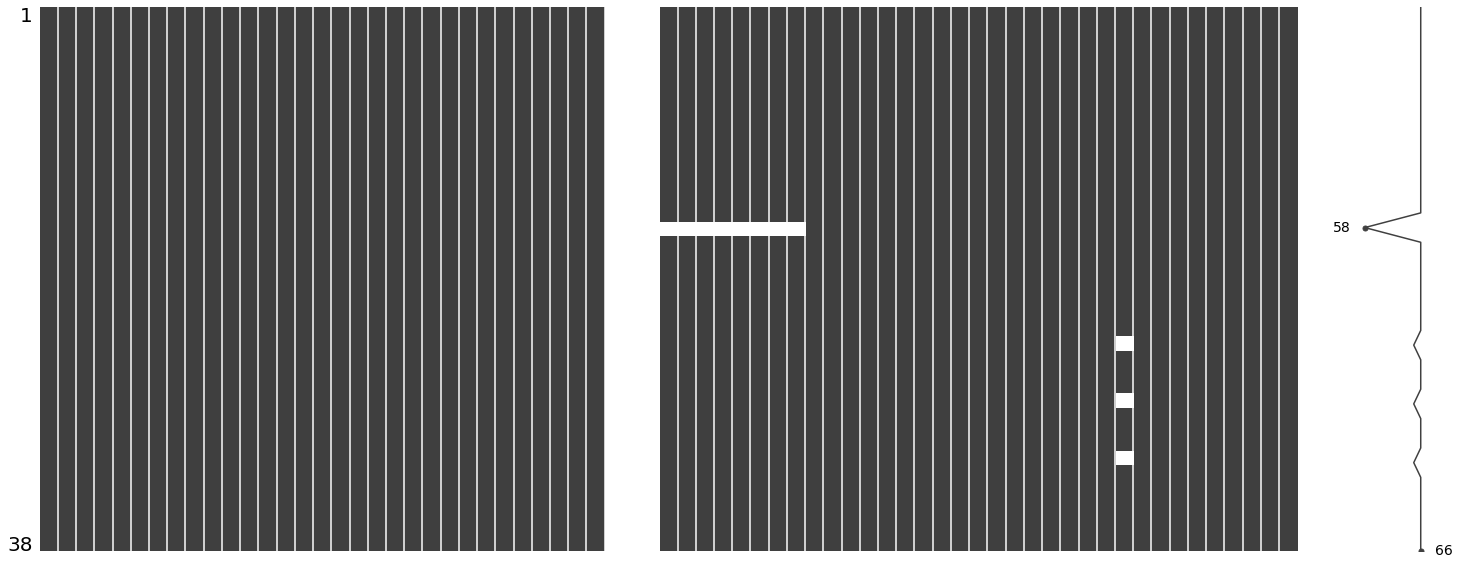

In [16]:
missingno.matrix(dataset_final)

In [17]:
cols = dataset_final.columns

In [18]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [19]:
len(cols)

69

In [20]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [21]:
len(rearranged)

69

In [22]:
dataset_final = dataset_final[rearranged]

In [23]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)